In [ ]:
from google.colab import drive
drive.mount('/content/drive/')

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


In [ ]:
import pandas as pd
import numpy as np
import math
from sklearn.model_selection import train_test_split as tts
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler as ss
from sklearn.metrics import accuracy_score,classification_report,precision_score,recall_score,f1_score,roc_auc_score,matthews_corrcoef

      age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  \
0      52    1   0       125   212    0        1      168      0      1.0   
1      53    1   0       140   203    1        0      155      1      3.1   
2      70    1   0       145   174    0        1      125      1      2.6   
3      61    1   0       148   203    0        1      161      0      0.0   
4      62    0   0       138   294    1        1      106      0      1.9   
...   ...  ...  ..       ...   ...  ...      ...      ...    ...      ...   
1020   59    1   1       140   221    0        1      164      1      0.0   
1021   60    1   0       125   258    0        0      141      1      2.8   
1022   47    1   0       110   275    0        0      118      1      1.0   
1023   50    0   0       110   254    0        0      159      0      0.0   
1024   54    1   0       120   188    0        1      113      0      1.4   

      slope  ca  thal  target  
0         2   2     3       0  
1         0

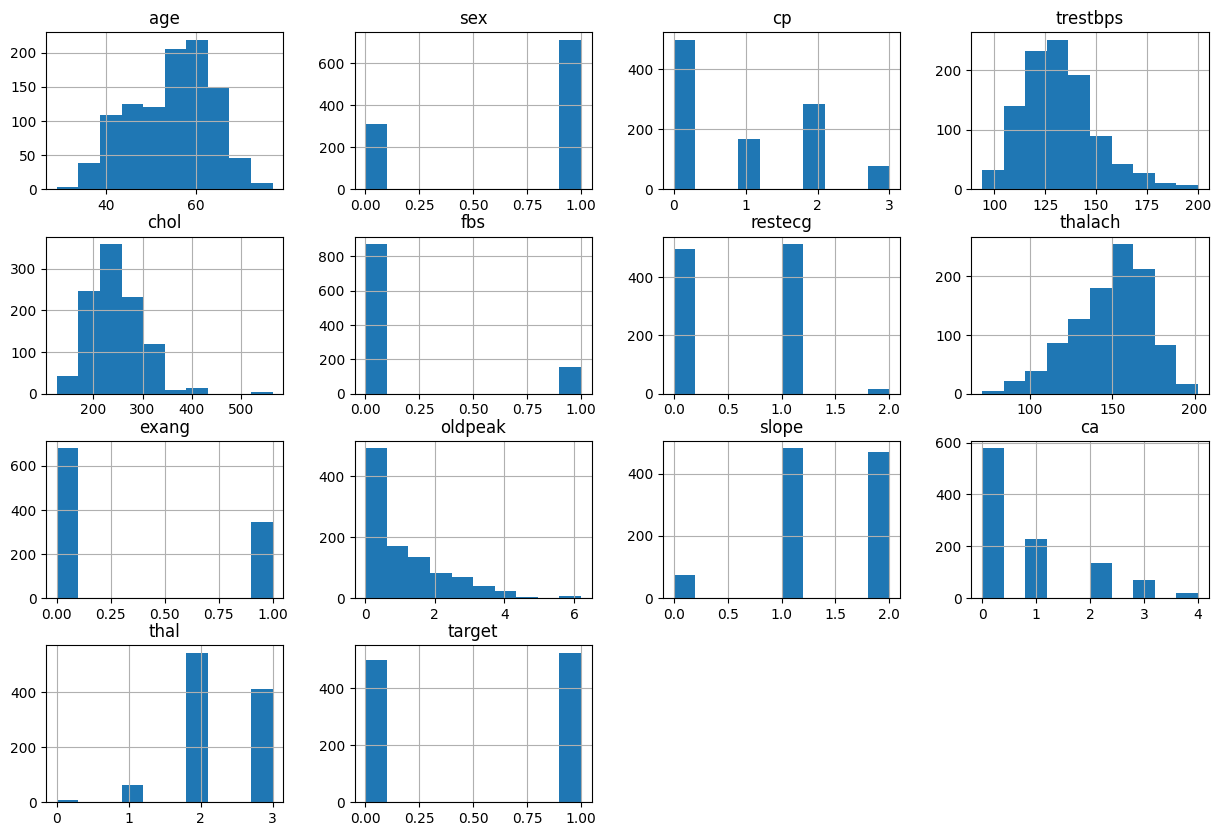

In [ ]:
df=pd.read_csv('/content/drive/My Drive/MachineLearning/heart.csv')
print(df)
print(df.corr()['target'])
print(df.info())
print(df.describe())
df.hist(figsize=(15,10))
plt.show()

In [ ]:
x=df.drop('target',axis=1)
y=df['target']

In [ ]:
s=ss()
xs=ss().fit_transform(x)

In [ ]:
xtr,xt,ytr,yt=tts(xs,y,test_size=0.2,shuffle=True)

In [ ]:
print(xtr.shape)

(820, 13)


In [ ]:
from sklearn.model_selection import GridSearchCV
param={'C':[0.1,1,10,100],'gamma':['scale','auto',0.01,0.1,1]}

In [ ]:
gs=GridSearchCV(SVC(kernel='rbf'),param,cv=5,scoring='accuracy')
gs.fit(xtr,ytr)
print("Best parameters:",gs.best_params_)
print("Best accuracy:",gs.best_score_)

Best parameters: {'C': 100, 'gamma': 'scale'}
Best accuracy: 0.9865853658536585


In [ ]:
bsvm=SVC(kernel='rbf',C=gs.best_params_['C'],gamma=gs.best_params_['gamma'])
bsvm.fit(xtr,ytr)

SVC(C=100)

In [ ]:
yp=bsvm.predict(xt)

In [ ]:
print("Test accuracy:",accuracy_score(yt,yp))
print("CLassification report:\n",classification_report(yt,yp))

Test accuracy: 0.9853658536585366
CLassification report:
               precision    recall  f1-score   support

           0       0.97      1.00      0.99       110
           1       1.00      0.97      0.98        95

    accuracy                           0.99       205
   macro avg       0.99      0.98      0.99       205
weighted avg       0.99      0.99      0.99       205



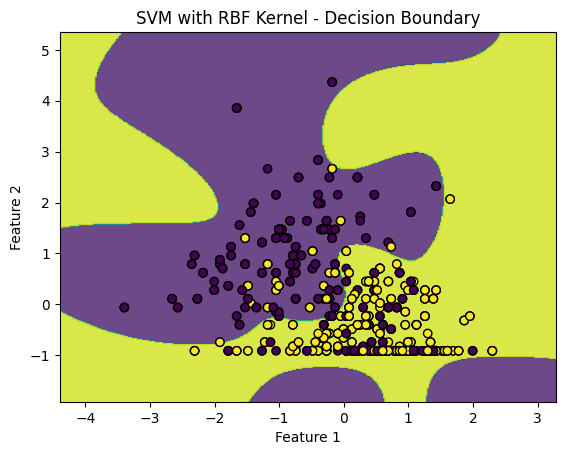

In [ ]:
bsvm.fit(xtr[:, [7,9]], ytr)
x_min, x_max = xtr[:, [7]].min() - 1, xtr[:, [7]].max() + 1
y_min, y_max = xtr[:, [9]].min() - 1, xtr[:, [9]].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

# Predict over the mesh grid
Z = bsvm.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)
plt.contourf(xx, yy, Z, alpha=0.8)

# Plot the training points
plt.scatter(xtr[:, [7]], xtr[:, [9]], c=ytr, edgecolors='k', marker='o')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('SVM with RBF Kernel - Decision Boundary')
plt.show()

In [ ]:
a=accuracy_score(yt,yp)
p=precision_score(yt,yp)
r=recall_score(yt,yp)
f=f1_score(yt,yp)
au=roc_auc_score(yt,yp)
m=matthews_corrcoef(yt,yp)
print(f"accuracy:{a}\nprecision:{p}\nrecall:{r}\nf1-score:{f}\nauc:{au}\nmcc:{m}")

accuracy:0.9853658536585366
precision:1.0
recall:0.968421052631579
f1-score:0.983957219251337
auc:0.9842105263157894
mcc:0.9709329323897106


In [ ]:
gs=GridSearchCV(SVC(kernel='linear'),param,cv=5,scoring='accuracy')
gs.fit(xtr,ytr)
print("Best parameters:",gs.best_params_)
print("Best accuracy:",gs.best_score_)

Best parameters: {'C': 0.1, 'gamma': 'scale'}
Best accuracy: 0.8439024390243901


In [ ]:
bsvm=SVC(kernel='linear',C=gs.best_params_['C'],gamma=gs.best_params_['gamma'])
bsvm.fit(xtr,ytr)

SVC(C=0.1, kernel='linear')

In [ ]:
yp=bsvm.predict(xt)

In [ ]:
print("Test accuracy:",accuracy_score(yt,yp))
print("CLassification report:\n",classification_report(yt,yp))

Test accuracy: 0.8536585365853658
CLassification report:
               precision    recall  f1-score   support

           0       0.93      0.78      0.85       110
           1       0.79      0.94      0.86        95

    accuracy                           0.85       205
   macro avg       0.86      0.86      0.85       205
weighted avg       0.87      0.85      0.85       205



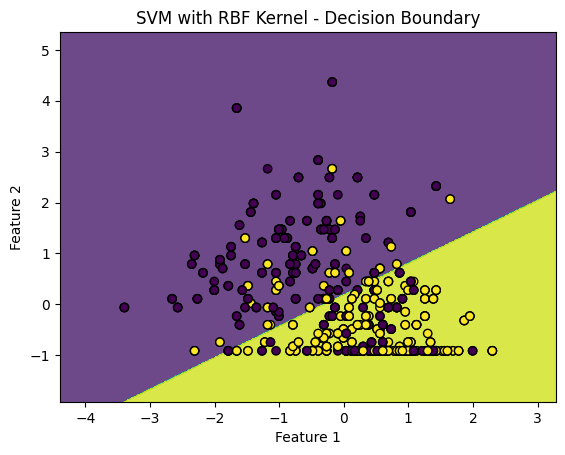

In [ ]:
bsvm.fit(xtr[:, [7,9]], ytr)
x_min, x_max = xtr[:, [7]].min() - 1, xtr[:, [7]].max() + 1
y_min, y_max = xtr[:, [9]].min() - 1, xtr[:, [9]].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

# Predict over the mesh grid
Z = bsvm.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)
plt.contourf(xx, yy, Z, alpha=0.8)

# Plot the training points
plt.scatter(xtr[:, [7]], xtr[:, [9]], c=ytr, edgecolors='k', marker='o')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('SVM with RBF Kernel - Decision Boundary')
plt.show()

In [ ]:
a=accuracy_score(yt,yp)
p=precision_score(yt,yp)
r=recall_score(yt,yp)
f=f1_score(yt,yp)
au=roc_auc_score(yt,yp)
m=matthews_corrcoef(yt,yp)
print(f"accuracy:{a}\nprecision:{p}\nrecall:{r}\nf1-score:{f}\nauc:{au}\nmcc:{m}")

accuracy:0.8536585365853658
precision:0.7876106194690266
recall:0.9368421052631579
f1-score:0.8557692307692307
auc:0.8593301435406699
mcc:0.7205243401429571
